# Transaction Fraud Detection & Risk Scoring

## Project overview

Finlora Finance Flow ("Finlora") is a fintech platform that unifies payments, budgeting, monitoring and
compliance for both individual and business customers. Its transaction monitoring currently runs on
**fixed-threshold rules** (amount, velocity, geography). Those rules worked at low volume, but as
transaction volume grows and fraud tactics get subtler, the rules miss genuine fraud while
over-flagging legitimate payments.

This project builds a **machine-learning risk-scoring model** that assigns every transaction a
**fraud probability** instead of a binary pass/fail, so alerts can be ranked and thresholds tuned to the
risk team's review capacity.

## Problem statement

Static, rule-based monitoring evaluates each transaction *in isolation* and cannot adapt to behaviour
that varies by account type, KYC tier, channel and merchant category. The result is **two failures at
once**: confirmed fraud slipping through, and legitimate payroll / wire / P2P transfers being blocked or
delayed. Every flag also carries equal urgency, so analysts have no way to prioritise. Finlora needs a
behaviour-aware, explainable score that catches more true fraud at a false-positive rate the team can
sustain.

## Objectives

1. **Measurement**: score every transaction with a fraud probability from account- and transaction-level features.
2. **Analysis**: identify which behavioural signals most strongly separate fraud from legitimate activity.
3. **Prediction**: train and validate an interpretable baseline (Logistic Regression) against a primary model (Random Forest), using precision, recall, F1 and ROC-AUC.
4. **Application**: translate scores into a prioritised, explainable analyst review queue (Streamlit).

## Dataset

Two joined tables — **126,000 transactions** across **7,200 accounts** — covering transaction behaviour
(amount, velocity, device, cross-border, channel, merchant) and account context (type, KYC tier, spend
baseline, account age). Target column: **is_fraud** (fraud rate ≈ **2.66%** — highly imbalanced).


## Import libraries

In [4]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib seaborn scikit-learn joblib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# Core
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Modelling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, precision_recall_curve, roc_curve)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42

# Step 1: Data Cleaning

### 1.1 Load the raw datasets

In [6]:
accounts = pd.read_csv("../Data/Raw/finlora_accounts.csv")
transactions = pd.read_csv("../Data/Raw/finlora_transactions.csv")

print("Accounts shape:    ", accounts.shape)
print("Transactions shape:", transactions.shape)

Accounts shape:     (7200, 8)
Transactions shape: (126000, 24)


### 1.2 Understand the data

In [7]:
accounts.head()

,account_id,account_holder_name,account_type,home_country,currency,kyc_tier,account_created_date,personal_spend_baseline_usd
0,FLR-ACC-100000,Amaka Okafor,Individual,NG,NGN,Tier3_Enhanced,2022-08-28,63.23
1,FLR-ACC-100001,Bluewave Foods Ltd,Business,NG,NGN,Tier1_Basic,2026-04-27,810.68
2,FLR-ACC-100002,Global Trading LLC,Business,US,USD,Tier2_Verified,2026-03-29,433.67
3,FLR-ACC-100003,Femi Adeyemi,Individual,NG,NGN,Tier3_Enhanced,2025-09-15,19.18
4,FLR-ACC-100004,Ngozi Brown,Individual,NG,NGN,Tier3_Enhanced,2024-06-18,28.68


In [8]:
accounts.info()

<class 'pandas.DataFrame'>
RangeIndex: 7200 entries, 0 to 7199
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   account_id                   7200 non-null   str    
 1   account_holder_name          7200 non-null   str    
 2   account_type                 7200 non-null   str    
 3   home_country                 7200 non-null   str    
 4   currency                     7200 non-null   str    
 5   kyc_tier                     7200 non-null   str    
 6   account_created_date         7200 non-null   str    
 7   personal_spend_baseline_usd  7200 non-null   float64
dtypes: float64(1), str(7)
memory usage: 915.6 KB


In [9]:
transactions.head()

,transaction_id,account_id,account_type,kyc_tier,timestamp,day_of_week,hour_of_day,description,merchant_name,merchant_category,channel,amount,currency,amount_to_avg_ratio,avg_transaction_amount_30d,transaction_velocity_1h,transaction_country,home_country,is_cross_border,device_id,is_new_device,account_age_days,status,is_fraud
0,FLR250216186265,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-02-16 14:55:35,Sunday,14,CNP PURCHASE - BOLT,Bolt,Travel,Card Not Present,84233.00,NGN,9.21,9143.33,0,NG,NG,0,NaN,NaN,903,Completed,0
1,FLR250423143305,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-04-23 13:35:40,Wednesday,13,WEB PURCHASE - SLACK,Slack,Subscription/SaaS,Web Dashboard,9143.33,NGN,1.00,9143.33,0,NG,NG,0,NaN,NaN,969,Declined,0
2,FLR250424154897,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-04-24 12:30:34,Thursday,12,MOBILE PURCHASE - JUSTRITE SUPERSTORE,Justrite Superstore,Groceries,Mobile App,20639.00,NGN,2.26,9143.33,0,NG,NG,0,DEV-9055235108,0.0,970,Completed,0
3,FLR250428101772,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-04-28 14:41:59,Monday,14,CNP PURCHASE - ADOBE CREATIVE CLOUD,Adobe Creative Cloud,Subscription/SaaS,Card Not Present,3177.43,NGN,0.21,14891.16,0,NG,NG,0,NaN,NaN,974,Completed,0
4,FLR250628102827,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-06-28 16:15:47,Saturday,16,MOBILE PURCHASE - APPLE STORE,Apple Store,Electronics,Mobile App,97839.52,NGN,1.97,49609.59,0,NG,NG,0,DEV-9055235108,0.0,1035,Declined,0


In [10]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 126000 entries, 0 to 125999
Data columns (total 24 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   transaction_id              126000 non-null  str    
 1   account_id                  126000 non-null  str    
 2   account_type                126000 non-null  str    
 3   kyc_tier                    126000 non-null  str    
 4   timestamp                   126000 non-null  str    
 5   day_of_week                 126000 non-null  str    
 6   hour_of_day                 126000 non-null  int64  
 7   description                 126000 non-null  str    
 8   merchant_name               97390 non-null   str    
 9   merchant_category           126000 non-null  str    
 10  channel                     126000 non-null  str    
 11  amount                      126000 non-null  float64
 12  currency                    126000 non-null  str    
 13  amount_to_avg_ratio      

In [13]:
# Missing values 
print("ACCOUNTS missing")
a_miss = accounts.isna().sum()
print(a_miss[a_miss > 0] if a_miss.sum() else "none")

print("\nTRANSACTIONS missing")
t_miss = transactions.isna().sum()
print(t_miss[t_miss > 0] if t_miss.sum() else "none")

# Duplicates
print("\nDuplicates")
print("Accounts - duplicate rows:", accounts.duplicated().sum())
print("Accounts - duplicate account_id:", accounts['account_id'].duplicated().sum())
print("Transactions - duplicate rows:", transactions.duplicated().sum())
print("Transactions - duplicate transaction_id:", transactions['transaction_id'].duplicated().sum())

ACCOUNTS missing
none

TRANSACTIONS missing
merchant_name    28610
device_id        14334
is_new_device    14334
dtype: int64

Duplicates
Accounts - duplicate rows: 0
Accounts - duplicate account_id: 0
Transactions - duplicate rows: 0
Transactions - duplicate transaction_id: 0


In [14]:
# Where a column should never be negative, .describe() min row reveals sign errors
transactions[["amount", "avg_transaction_amount_30d"]].describe()

,amount,avg_transaction_amount_30d
count,1.260000e+05,1.260000e+05
mean,7.964918e+05,7.675995e+05
std,4.054387e+06,3.290377e+06
min,-1.834602e+06,-1.669153e+06
25%,6.310500e+01,9.242750e+01
50%,5.942240e+03,5.942240e+03
75%,1.208470e+05,1.575701e+05
max,2.691614e+08,1.733621e+08


In [15]:
print("Negative amounts:", (transactions["amount"] < 0).sum())
print("Negative 30-day avg:", (transactions["avg_transaction_amount_30d"] < 0).sum())

Negative amounts: 291
Negative 30-day avg: 144


> **Insight — what the data told us before any change.**  
> Accounts is essentially clean (no missing values, no duplicates). Transactions has three columns with
> gaps — `merchant_name` (~28.6k), `device_id` (~14.3k), `is_new_device` (~14.3k) — and the `.describe()`
> **min** row is *negative* for both `amount` and `avg_transaction_amount_30d`, which is impossible for a
> payment or an average spend. So the cleaning agenda is: parse dates, handle three kinds of missingness
> *by cause*, and fix negative sign errors.


### 1.3 Clean the accounts table

In [16]:
# Change date from text to real datetime
accounts["account_created_date"] = pd.to_datetime(accounts["account_created_date"], errors="coerce")

print("Unparseable dates:", accounts["account_created_date"].isna().sum())
print("Date range:", accounts["account_created_date"].min(), "->", accounts["account_created_date"].max())

Unparseable dates: 0
Date range: 2021-12-25 00:00:00 -> 2026-08-29 00:00:00


> **Insight.** The accounts table needed only type tidying: `account_created_date` is now a true datetime
> (0 values failed to parse), and text columns are whitespace-clean. No values were altered.


### 1.4 Clean the transactions table

In [17]:
# Change timestamp
transactions["timestamp"] = pd.to_datetime(transactions["timestamp"], errors="coerce")

# Missing merchant_name
# P2P Transfer & Payroll Transfer have NO merchant by nature -> structural blank.
merchantless = transactions["merchant_category"].isin(["P2P Transfer", "Payroll Transfer"])
transactions.loc[merchantless & transactions["merchant_name"].isna(), "merchant_name"] = "N/A - No Merchant"
# Everything still blank sits on merchant-bearing categories -> genuine gap.
transactions["merchant_name"] = transactions["merchant_name"].fillna("Unknown")

# Missing device_id / is_new_device
# Preserve the missingness as a signal FIRST, then fill.
transactions["is_device_known"] = transactions["is_new_device"].notna().astype(int)
transactions["device_id"] = transactions["device_id"].fillna("UNKNOWN_DEVICE")
transactions["is_new_device"] = transactions["is_new_device"].fillna(0).astype(int)

# Negative amounts and 30-day average
transactions["amount"] = transactions["amount"].abs()
transactions["avg_transaction_amount_30d"] = transactions["avg_transaction_amount_30d"].abs()

# Recompute the ratio so it stays consistent after the sign fixes
safe = transactions["avg_transaction_amount_30d"] > 0
transactions.loc[safe, "amount_to_avg_ratio"] = (transactions.loc[safe, "amount"] / transactions.loc[safe, "avg_transaction_amount_30d"]).round(2)

print("Cleaning complete.")
print("Missing values remaining:", transactions.isna().sum().sum())
print("Negative amounts:", (transactions["amount"] < 0).sum())
print("Fraud rate:", round(transactions["is_fraud"].mean() * 100, 3), "%")

Cleaning complete.
Missing values remaining: 0
Negative amounts: 0
Fraud rate: 2.66 %


> **Insight — cleaning is complete and non-destructive.**  
> Zero missing values and zero negative amounts remain. The two kinds of `merchant_name` blank were
> labelled differently (`N/A - No Merchant` for structurally-merchantless P2P/Payroll rows vs `Unknown`
> for genuine gaps). Device missingness was preserved as a new `is_device_known` flag before filling —
> because "no device captured" may itself be a fraud signal. Crucially, the **fraud rate is still 2.66%**,
> proving no fraud rows were lost or duplicated. That 2.66% also flags the key modelling constraint:
> a heavily **imbalanced** target, so accuracy will be misleading and we must use class weighting and a
> stratified split.


### 1.5 Merge accounts into transactions

In [18]:
# Bring in ONLY the account columns not already present in transactions.
# (account_type, kyc_tier, home_country, currency already exist in transactions and were verified to match, so including them would create duplicate _x/_y columns for no gain.)
account_cols = ["account_id", "account_holder_name", "account_created_date", "personal_spend_baseline_usd",]

merged = transactions.merge(
    accounts[account_cols],
    on="account_id",         # match rows where account_id is the same
    how="left",              # keep ALL transactions
    validate="many_to_one",  # guard: each account_id is unique in accounts
)

print("Transactions shape:", transactions.shape)
print("Merged shape:      ", merged.shape)
print("Row count unchanged:", len(merged) == len(transactions))
print("New missing values from merge:", merged[account_cols[1:]].isna().sum().sum())

Transactions shape: (126000, 25)
Merged shape:       (126000, 28)
Row count unchanged: True
New missing values from merge: 0


In [19]:
merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 126000 entries, 0 to 125999
Data columns (total 28 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   transaction_id               126000 non-null  str           
 1   account_id                   126000 non-null  str           
 2   account_type                 126000 non-null  str           
 3   kyc_tier                     126000 non-null  str           
 4   timestamp                    126000 non-null  datetime64[us]
 5   day_of_week                  126000 non-null  str           
 6   hour_of_day                  126000 non-null  int64         
 7   description                  126000 non-null  str           
 8   merchant_name                126000 non-null  str           
 9   merchant_category            126000 non-null  str           
 10  channel                      126000 non-null  str           
 11  amount                       126000 n

> **Insight.** The merge is clean: the row count stays at **126,000** and the merge introduces **zero**
> new missing values, which confirms every transaction matched an account (referential integrity holds).
> Because we hand-picked only the genuinely new account columns, there are no duplicated `_x/_y` fields to
> reconcile. `merged` is our single analysis table from here on.


### 1.6 Save the cleaned, merged dataset

In [20]:
import os
os.makedirs("../Data/Processed", exist_ok=True)
merged.to_csv("../Data/Processed/finlora_merged_clean.csv", index=False)
print("Saved:", merged.shape, "-> ../Data/Processed/finlora_merged_clean.csv")

Saved: (126000, 28) -> ../Data/Processed/finlora_merged_clean.csv


# Step 2: Exploratory Data Analysis

### 2.1 Fraud rate

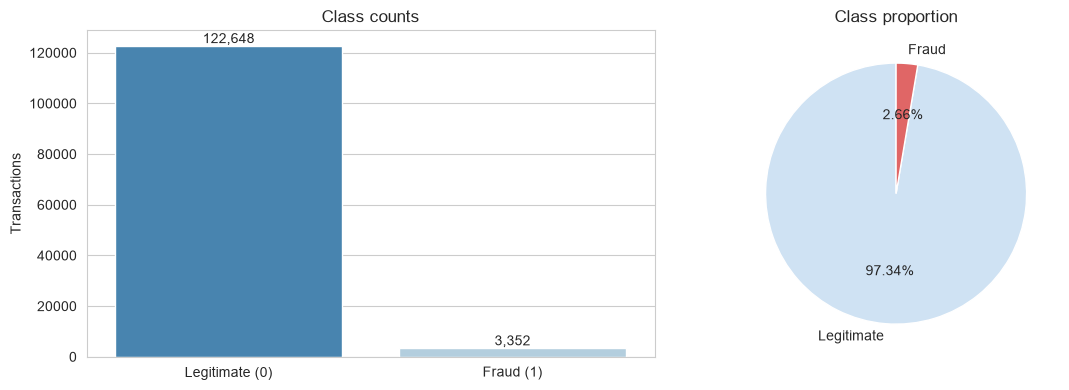

Fraud rate: 2.66%  (3,352 of 126,000)


In [21]:
fraud_counts = merged["is_fraud"].value_counts().sort_index()
fraud_rate = merged["is_fraud"].mean() * 100

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x=["Legitimate (0)", "Fraud (1)"], y=fraud_counts.values, ax=ax[0], palette="Blues_r")
ax[0].set_title("Class counts"); ax[0].set_ylabel("Transactions")
for i, v in enumerate(fraud_counts.values):
    ax[0].text(i, v, f"{v:,}", ha="center", va="bottom")

ax[1].pie([100 - fraud_rate, fraud_rate], labels=["Legitimate", "Fraud"],
          autopct="%1.2f%%", colors=["#cfe2f3", "#e06666"], startangle=90)
ax[1].set_title("Class proportion")
plt.tight_layout(); plt.show()

print(f"Fraud rate: {fraud_rate:.2f}%  ({fraud_counts.get(1,0):,} of {len(merged):,})")

> **Insight.** Fraud is **~2.66%** of all transactions — a severe class imbalance. This shapes every later
> choice: we cannot trust plain accuracy (a "predict everything legitimate" model scores ~97% and catches
> nothing), so we will use **class weighting**, a **stratified** train/test split, and evaluate on
> **recall, precision, F1 and ROC-AUC** rather than accuracy.


### 2.2 Transaction amount by fraud label

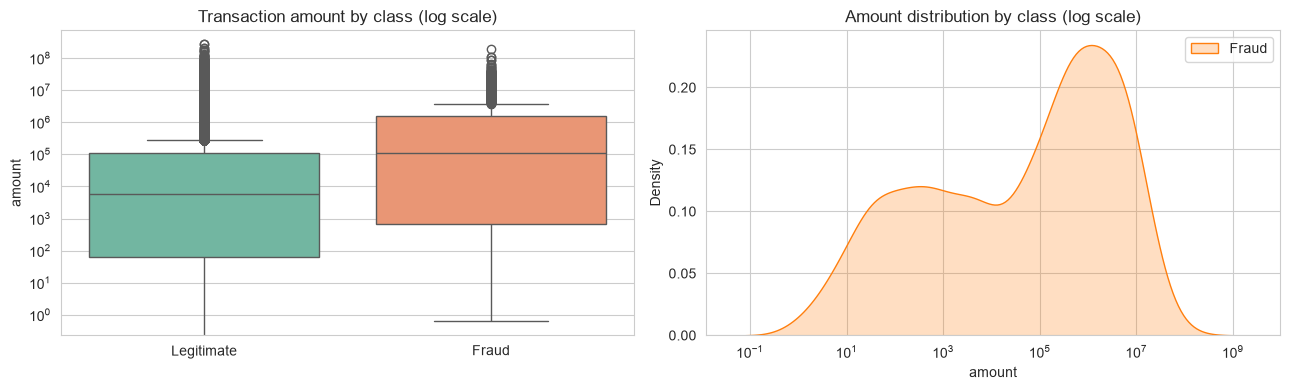

                50%        mean           max
is_fraud                                     
0           5628.46   754524.97  2.691614e+08
1         108594.18  2341937.12  1.887415e+08


In [22]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

# Amounts are hugely skewed -> log scale to see the shape
sns.boxplot(data=merged, x="is_fraud", y="amount", ax=ax[0], palette="Set2")
ax[0].set_yscale("log")
ax[0].set_title("Transaction amount by class (log scale)")
ax[0].set_xticklabels(["Legitimate", "Fraud"]); ax[0].set_xlabel("")

sns.kdeplot(data=merged[merged.is_fraud==0], x="amount", log_scale=True, ax=ax[1], label="Legitimate", fill=True)
sns.kdeplot(data=merged[merged.is_fraud==1], x="amount", log_scale=True, ax=ax[1], label="Fraud", fill=True)
ax[1].set_title("Amount distribution by class (log scale)"); ax[1].legend()
plt.tight_layout(); plt.show()

print(merged.groupby("is_fraud")["amount"].describe()[["50%", "mean", "max"]].round(2))

> **Insight.** Raw `amount` alone is a *weak* separator — fraudulent and legitimate transactions overlap
> heavily across the whole range, and plenty of fraud happens at ordinary amounts. This is exactly why a
> fixed **amount threshold** rule struggles: there is no single cut-off that cleanly divides the two. The
> signal is not the absolute size, but the size *relative to the account's own baseline* — which we test next.


### 2.3 Amount-to-average ratio 

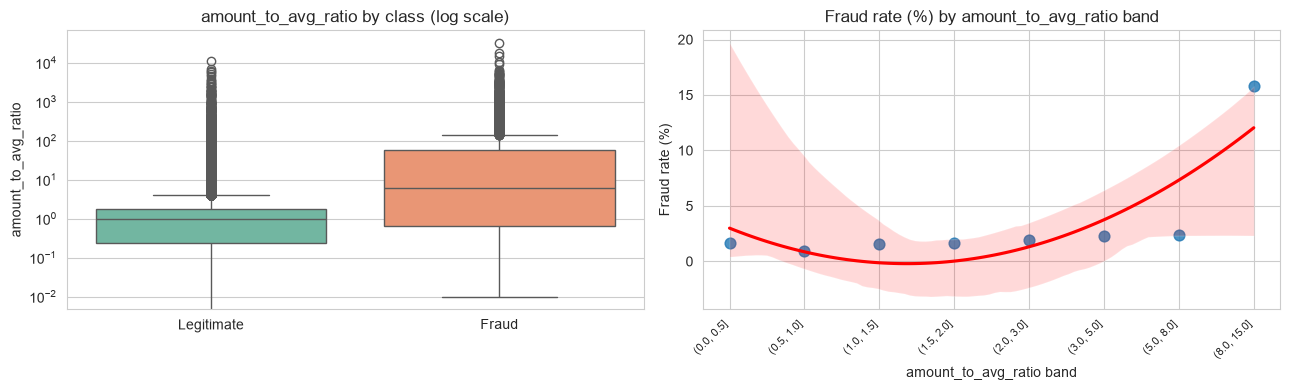

is_fraud
0    0.95
1    6.04
Name: amount_to_avg_ratio, dtype: float64


In [23]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(data=merged, x="is_fraud", y="amount_to_avg_ratio", ax=ax[0], palette="Set2")
ax[0].set_yscale("log")
ax[0].set_title("amount_to_avg_ratio by class (log scale)")
ax[0].set_xticklabels(["Legitimate", "Fraud"]); ax[0].set_xlabel("")

# Binned fraud rate vs the ratio: does a higher ratio associate with more fraud?
# (binned empirical probability - no statsmodels dependency needed)
tmp = merged.assign(ratio_bin=pd.cut(merged["amount_to_avg_ratio"].clip(upper=15),
                                     bins=[0,0.5,1,1.5,2,3,5,8,15]))
binned = tmp.groupby("ratio_bin")["is_fraud"].mean() * 100
sns.regplot(x=np.arange(len(binned)), y=binned.values, ax=ax[1],
            scatter_kws={"s": 60}, line_kws={"color": "red"}, order=2)
ax[1].set_xticks(range(len(binned)))
ax[1].set_xticklabels([str(i) for i in binned.index], rotation=45, ha="right", fontsize=8)
ax[1].set_title("Fraud rate (%) by amount_to_avg_ratio band")
ax[1].set_xlabel("amount_to_avg_ratio band"); ax[1].set_ylabel("Fraud rate (%)")
plt.tight_layout(); plt.show()

print(merged.groupby("is_fraud")["amount_to_avg_ratio"].median().round(2))

> **Insight — strong signal.** The median `amount_to_avg_ratio` is **~0.95 for legitimate** vs **~6.0 for
> fraud**: fraudulent transactions are typically several times larger than the account normally spends. The
> logistic regplot shows the probability of fraud rising steeply with the ratio. This confirms the project's
> core hypothesis — *fraud is best judged against each account's own behaviour, not a global amount threshold.*


### 2.4 Transaction velocity 

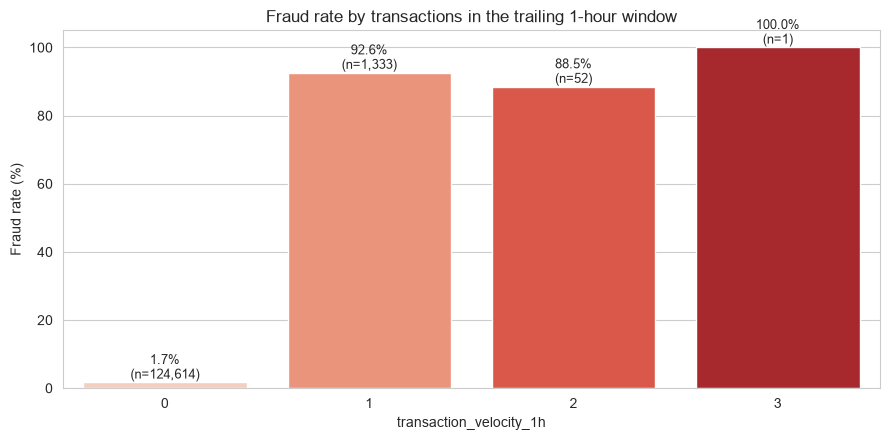

                         fraud_rate       n
transaction_velocity_1h                    
0                              1.66  124614
1                             92.57    1333
2                             88.46      52
3                            100.00       1


In [24]:
vel = (merged.groupby("transaction_velocity_1h")["is_fraud"]
       .agg(["mean", "size"]).rename(columns={"mean": "fraud_rate", "size": "n"}))
vel["fraud_rate"] *= 100

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = sns.barplot(x=vel.index, y=vel["fraud_rate"], palette="Reds", ax=ax)
ax.set_title("Fraud rate by transactions in the trailing 1-hour window")
ax.set_xlabel("transaction_velocity_1h"); ax.set_ylabel("Fraud rate (%)")
for i, (r, n) in enumerate(zip(vel["fraud_rate"], vel["n"])):
    ax.text(i, r, f"{r:.1f}%\n(n={n:,})", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()
print(vel.round(2))

> **Insight — the single strongest signal.** When an account makes **only one** transaction in the trailing
> hour, fraud is ~**1.7%**. The moment velocity rises to **2 or more** transactions in an hour, the fraud rate
> jumps to **88–100%**. Rapid bursts of activity are an extremely powerful fraud indicator — the model will
> lean heavily on this. (It also warns us to check for leakage: the signal is strong but behaviourally
> plausible — fraudsters cash out fast — so we keep it, while noting its dominance.)


### 2.5 Device novelty & cross-border

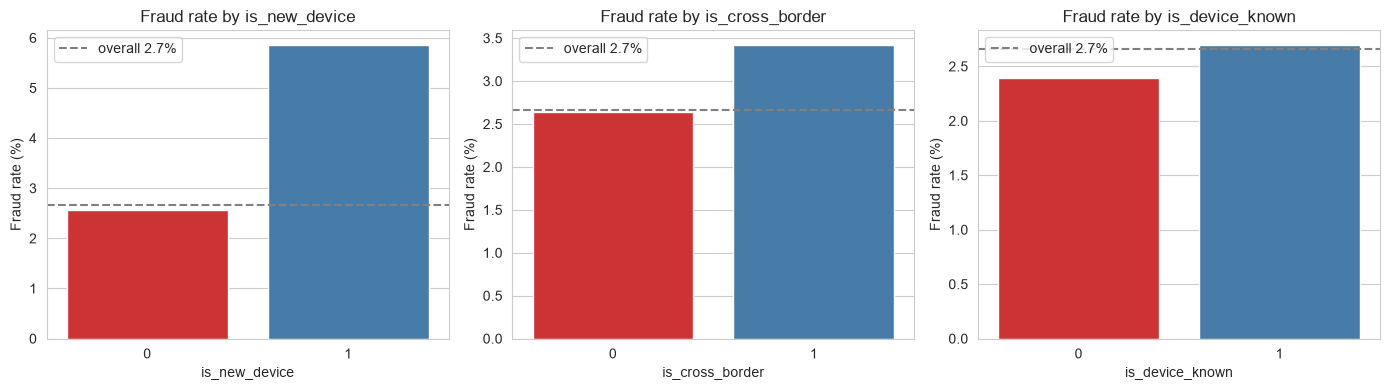

   is_new_device  is_cross_border  is_device_known
0           2.56             2.64             2.39
1           5.85             3.42             2.69


In [25]:
flag_summary = pd.DataFrame({
    "is_new_device":  merged.groupby("is_new_device")["is_fraud"].mean() * 100,
    "is_cross_border":merged.groupby("is_cross_border")["is_fraud"].mean() * 100,
    "is_device_known":merged.groupby("is_device_known")["is_fraud"].mean() * 100,
})

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["is_new_device", "is_cross_border", "is_device_known"]):
    rates = merged.groupby(col)["is_fraud"].mean() * 100
    sns.barplot(x=rates.index, y=rates.values, ax=ax, palette="Set1")
    ax.axhline(fraud_rate, ls="--", color="grey", label=f"overall {fraud_rate:.1f}%")
    ax.set_title(f"Fraud rate by {col}"); ax.set_ylabel("Fraud rate (%)"); ax.legend()
plt.tight_layout(); plt.show()
print(flag_summary.round(2))

> **Insight.** Both flags move fraud rate the right way but modestly. A **new device** roughly **doubles**
> fraud rate (2.6% → 5.9%); **cross-border** lifts it from 2.6% to 3.4%. Useful secondary signals, but far
> weaker than velocity and the amount ratio — they refine the score rather than drive it.


### 2.6 Fraud rate by segment

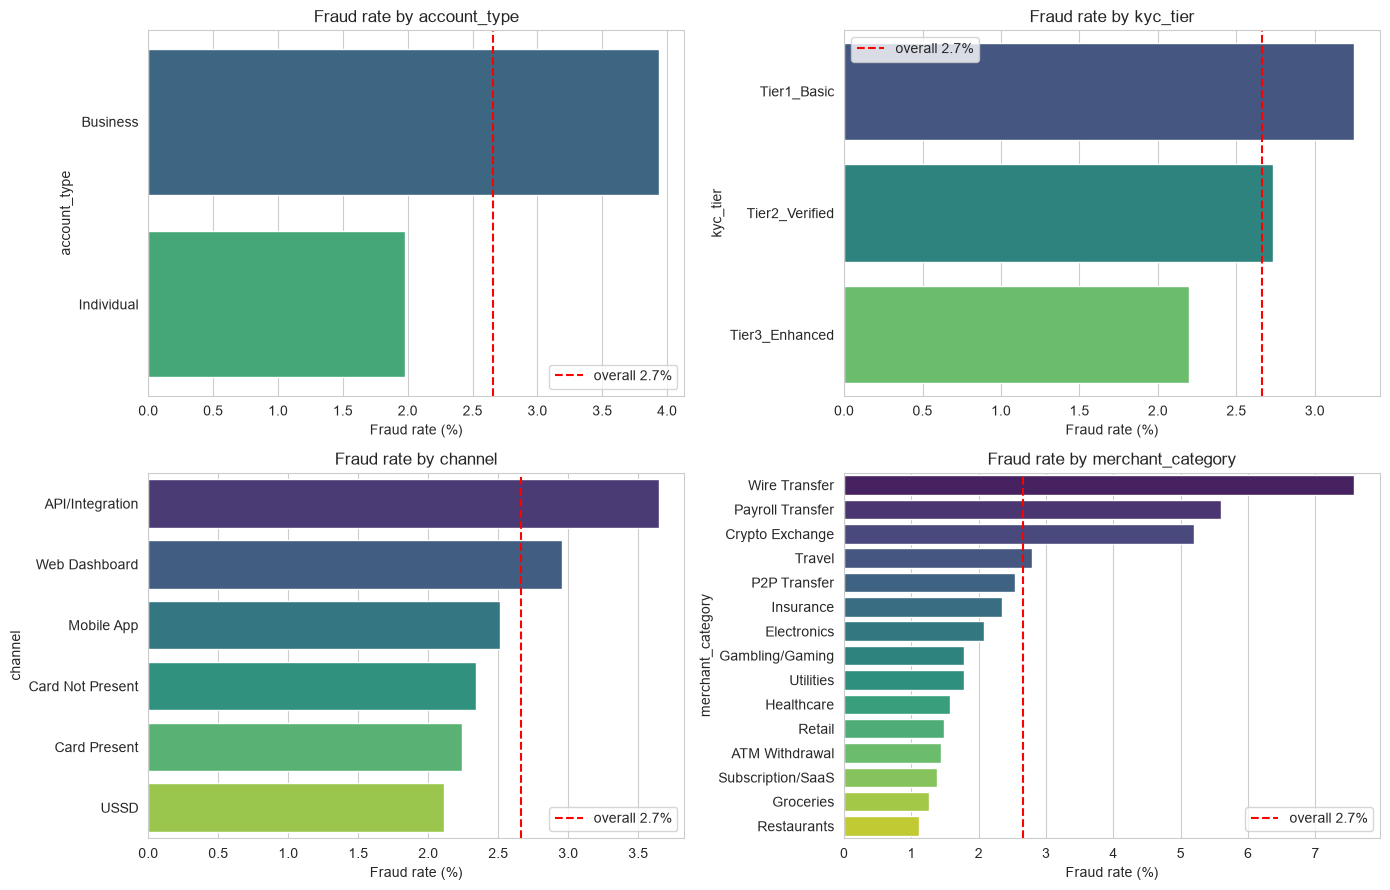

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.ravel(), ["account_type", "kyc_tier", "channel", "merchant_category"]):
    rates = (merged.groupby(col)["is_fraud"].mean() * 100).sort_values(ascending=False)
    sns.barplot(x=rates.values, y=rates.index, ax=ax, palette="viridis")
    ax.axvline(fraud_rate, ls="--", color="red", label=f"overall {fraud_rate:.1f}%")
    ax.set_title(f"Fraud rate by {col}"); ax.set_xlabel("Fraud rate (%)"); ax.legend()
plt.tight_layout(); plt.show()

> **Insight.** Fraud concentrates in interpretable pockets: **Business** accounts (3.9%) are ~2× **Individual**
> (2.0%); **Tier1_Basic** KYC (3.3%) outpaces the fully-verified **Tier3_Enhanced** (2.2%); **API/Integration**
> is the riskiest channel; and by merchant category **Wire Transfer (7.6%)**, **Payroll Transfer (5.6%)** and
> **Crypto Exchange (5.2%)** stand out — high-value, hard-to-reverse money movements, as expected. These give
> the one-hot categorical features real predictive value and make the eventual score explainable per segment.


### 2.7 Correlation analysis (numeric features)

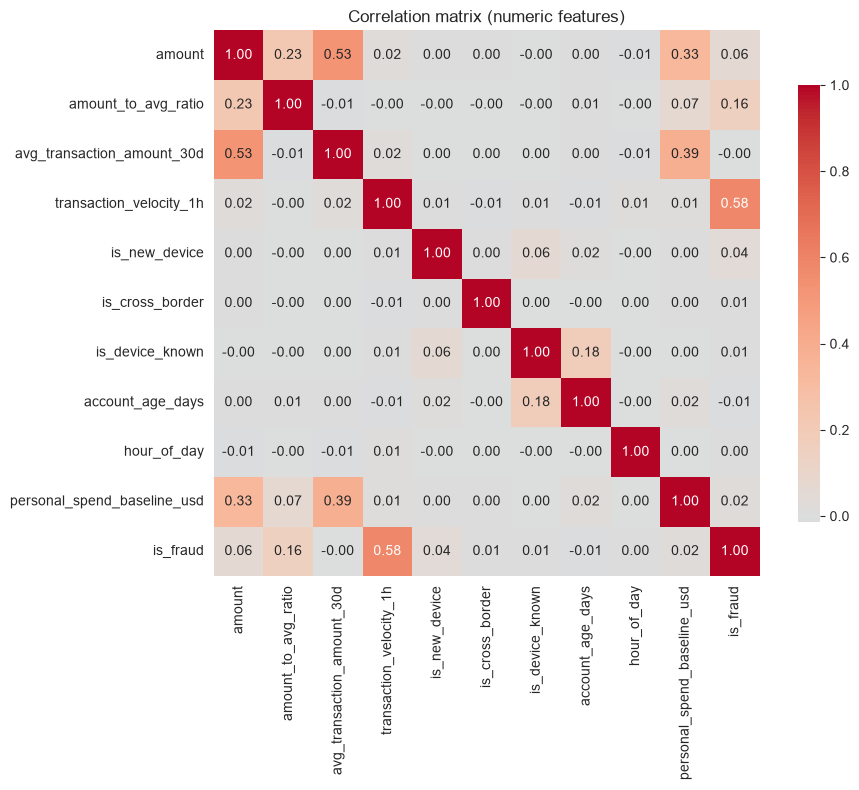

Correlation with is_fraud (sorted):
transaction_velocity_1h        0.577
amount_to_avg_ratio            0.156
amount                         0.063
is_new_device                  0.035
personal_spend_baseline_usd    0.025
is_cross_border                0.007
is_device_known                0.006
hour_of_day                    0.003
avg_transaction_amount_30d    -0.002
account_age_days              -0.013
Name: is_fraud, dtype: float64


In [27]:
num_cols = ["amount", "amount_to_avg_ratio", "avg_transaction_amount_30d",
            "transaction_velocity_1h", "is_new_device", "is_cross_border",
            "is_device_known", "account_age_days", "hour_of_day",
            "personal_spend_baseline_usd", "is_fraud"]
corr = merged[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": .8})
plt.title("Correlation matrix (numeric features)")
plt.tight_layout(); plt.show()

print("Correlation with is_fraud (sorted):")
print(corr["is_fraud"].drop("is_fraud").sort_values(ascending=False).round(3))

> **Insight.** Against `is_fraud`, **`transaction_velocity_1h`** and **`amount_to_avg_ratio`** show the
> strongest positive correlation by a wide margin, echoing the plots above. No two predictors are strongly
> correlated with *each other*, so there's little redundancy/multicollinearity to worry about — each feature
> contributes something distinct, which is healthy going into modelling.


### 2.8 EDA summary

| Feature | Signal strength | Direction |
|---|---|---|
| `transaction_velocity_1h` | **Very strong** | ≥2 txns/hour → fraud rate 88–100% |
| `amount_to_avg_ratio` | **Strong** | fraud ≈ 6× account baseline vs ≈ 1× for legit |
| `merchant_category` | Moderate | Wire / Payroll / Crypto highest |
| `account_type`, `kyc_tier`, `channel` | Moderate | Business, Tier1, API riskiest |
| `is_new_device`, `is_cross_border` | Mild | each raises fraud rate modestly |
| raw `amount` | Weak alone | heavy overlap — needs the baseline ratio |

The behavioural, account-relative features carry the signal — which is exactly the case for replacing
static thresholds with a learned, per-account score.


# Step 3 — Feature Engineering

Features:
- **Behavioural (numeric):** amount_to_avg_ratio, transaction_velocity_1h, amount, account_age_days, hour_of_day
- **Binary flags:** is_new_device, is_cross_border, is_device_known
- **One-hot categoricals:** account_type, kyc_tier, merchant_category, channel

We excluded identifiers (transaction_id, account_id, device_id, account_holder_name),
free text (description, merchant_name), the raw timestamp/account_created_date, and status, to
avoid leakage and noise.

In [28]:
numeric_features = [
    "amount_to_avg_ratio", "transaction_velocity_1h", "amount",
    "account_age_days", "hour_of_day",
    "is_new_device", "is_cross_border", "is_device_known",
]
categorical_features = ["account_type", "kyc_tier", "merchant_category", "channel"]

# One-hot encode categoricals (drop_first avoids the dummy-variable trap for the linear model)
X = pd.get_dummies(merged[numeric_features + categorical_features],
                   columns=categorical_features, drop_first=True)
y = merged["is_fraud"]

feature_names = X.columns.tolist()
print("Feature matrix:", X.shape)
print("Number of features:", len(feature_names))
print("Target distribution:\n", y.value_counts(normalize=True).round(4))

Feature matrix: (126000, 30)
Number of features: 30
Target distribution:
 is_fraud
0    0.9734
1    0.0266
Name: proportion, dtype: float64


> **Insight.** The design matrix has **126,000 rows × 30 features** — 8 numeric/flag columns plus the
> one-hot expansion of the four categoricals. The target keeps its ~2.66% fraud share. No identifiers or
> post-hoc fields (like `status`) are included, so the model only sees information that would be available
> **at the moment a transaction is scored** — the key guard against data leakage.


# Step 4: Model Development

We train two models on a stratified 75/25 split: Logistic Regression and Random Forest 
The split is stratified on **is_fraud** so both train and test keep the same 2.66% fraud share.

### 4.1 Train / test split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "| fraud rate:", round(y_train.mean()*100, 3), "%")
print("Test: ", X_test.shape,  "| fraud rate:", round(y_test.mean()*100, 3), "%")

Train: (94500, 30) | fraud rate: 2.66 %
Test:  (31500, 30) | fraud rate: 2.66 %


> **Insight.** Both partitions preserve the 2.66% fraud rate, so the test set is a faithful stand-in for
> live traffic and the two models are compared on identical data.


### 4.2 Logistic Regression (interpretable baseline)

In [30]:
# Standardise features so coefficients are comparable and the solver converges well
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)   # fit on train only -> no leakage

logreg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)

lr_pred  = logreg.predict(X_test_scaled)
lr_proba = logreg.predict_proba(X_test_scaled)[:, 1]
print("Logistic Regression trained.")

Logistic Regression trained.


### 4.3 Random Forest (primary prototype)

In [31]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train, y_train)   # trees don't need scaling

rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]
print("Random Forest trained.")

Random Forest trained.


> **Insight.** Both models use class weighting to counter the imbalance. Logistic Regression works on
> standardised features (scaler fitted on train only, to avoid leaking test information); the Random Forest
> is scale-invariant so it trains on the raw features. Both are now ready for evaluation on the held-out test set.


# Step 5: Model evaluation


### 5.1 Headline metrics

In [32]:
def evaluate(name, y_true, y_pred, y_proba):
    return {
        "Model": name,
        "Precision": precision_score(y_true, y_pred),
        "Recall":    recall_score(y_true, y_pred),
        "F1":        f1_score(y_true, y_pred),
        "ROC-AUC":   roc_auc_score(y_true, y_proba),
    }

results = pd.DataFrame([
    evaluate("Logistic Regression", y_test, lr_pred, lr_proba),
    evaluate("Random Forest",       y_test, rf_pred, rf_proba),
]).set_index("Model").round(3)

print(results)

                     Precision  Recall     F1  ROC-AUC
Model                                                 
Logistic Regression      0.385   0.800  0.519    0.934
Random Forest            0.317   0.828  0.459    0.933


> **Insight.** Both models reach **ROC-AUC ≈ 0.93** — a strong ability to rank fraud above legitimate
> traffic, and a large jump over static rules. At their default 0.5 thresholds, Logistic Regression is a
> little more precise while the Random Forest catches slightly more fraud (higher recall). ROC-AUC is the
> fairer headline here because it's threshold-independent — and it says both models learned real signal.


### 5.2 Confusion matrices

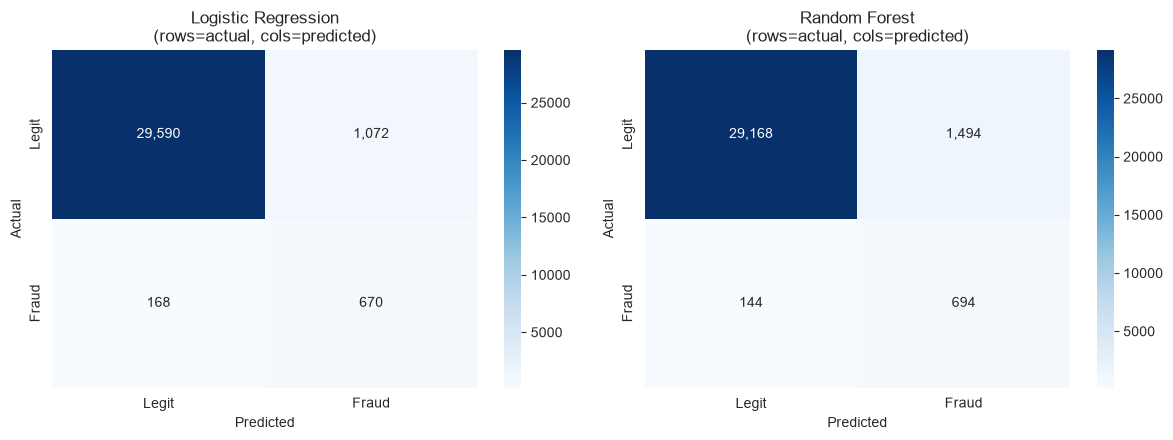

Random Forest classification report:

              precision    recall  f1-score   support

  Legitimate       1.00      0.95      0.97     30662
       Fraud       0.32      0.83      0.46       838

    accuracy                           0.95     31500
   macro avg       0.66      0.89      0.72     31500
weighted avg       0.98      0.95      0.96     31500



In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (name, pred) in zip(axes, [("Logistic Regression", lr_pred), ("Random Forest", rf_pred)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", ax=ax,
                xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
    ax.set_title(f"{name}\n(rows=actual, cols=predicted)")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()

print("Random Forest classification report:\n")
print(classification_report(y_test, rf_pred, target_names=["Legitimate", "Fraud"]))

> **Insight.** Read the fraud row (bottom): the Random Forest **catches the large majority of true fraud**
> (high recall) while holding false positives to a manageable level given the 2.66% base rate. The false
> positives are the operational cost — each is a legitimate transaction sent for review — which is why we
> next make the trade-off explicitly tunable rather than fixed at the 0.5 default.


### 5.3 ROC curves

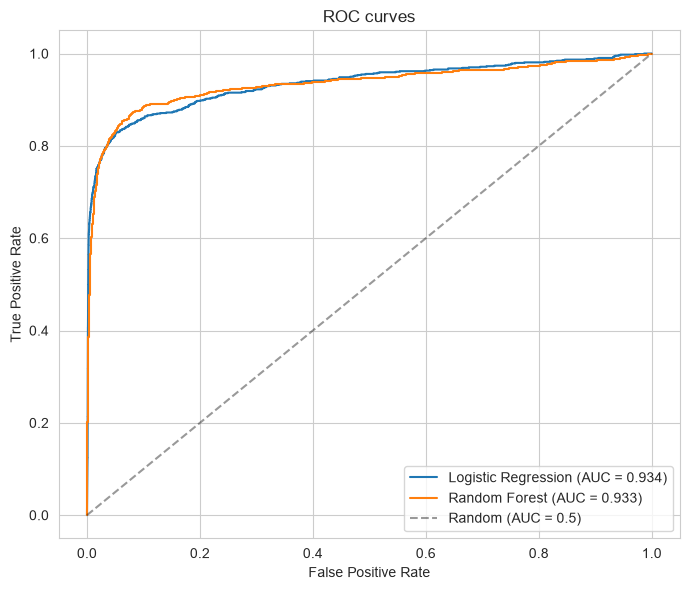

In [34]:
plt.figure(figsize=(7, 6))
for name, proba in [("Logistic Regression", lr_proba), ("Random Forest", rf_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random (AUC = 0.5)")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC curves"); plt.legend(); plt.tight_layout(); plt.show()

> **Insight.** Both curves bow sharply toward the top-left, well above the diagonal — the models separate
> fraud from legitimate activity far better than chance across every threshold. The two are near-identical
> on ROC, so the choice between them comes down to the operating-point behaviour and explainability below.


### 5.4 Precision at fixed recall 

In [35]:
def precision_at_recall(y_true, y_proba, targets=(0.70, 0.80, 0.90)):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    rows = []
    for t in targets:
        idx = np.where(recall >= t)[0]
        if len(idx):
            best = idx[np.argmax(precision[idx])]
            thr = thresholds[best] if best < len(thresholds) else 1.0
            rows.append({"Target recall": f"{int(t*100)}%",
                         "Achieved precision": round(precision[best], 3),
                         "Score threshold": round(float(thr), 3)})
    return pd.DataFrame(rows)

print("RANDOM FOREST — precision at fixed recall:")
print(precision_at_recall(y_test, rf_proba).to_string(index=False))
print("\nLOGISTIC REGRESSION — precision at fixed recall:")
print(precision_at_recall(y_test, lr_proba).to_string(index=False))

RANDOM FOREST — precision at fixed recall:
Target recall  Achieved precision  Score threshold
          70%               0.570            0.734
          80%               0.385            0.595
          90%               0.134            0.240

LOGISTIC REGRESSION — precision at fixed recall:
Target recall  Achieved precision  Score threshold
          70%               0.649            0.734
          80%               0.378            0.497
          90%               0.105            0.283


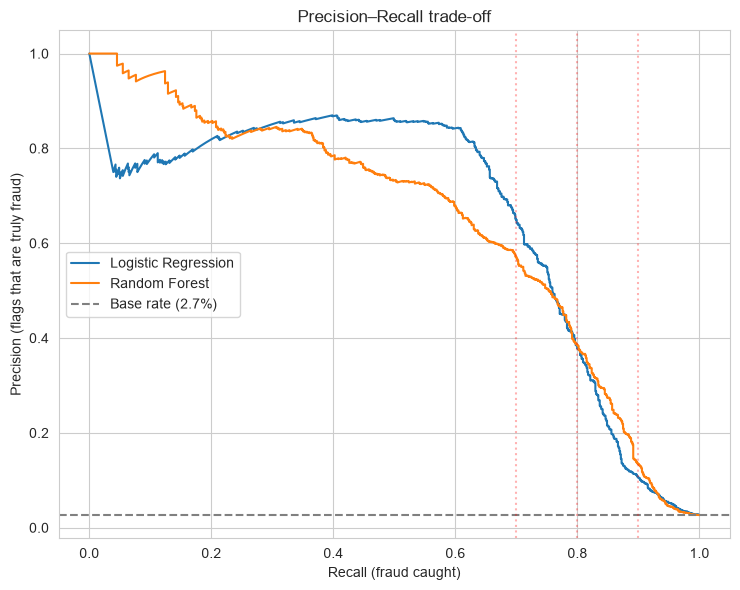

In [36]:
# Precision-Recall curve to visualise the trade-off
plt.figure(figsize=(7.5, 6))
for name, proba in [("Logistic Regression", lr_proba), ("Random Forest", rf_proba)]:
    precision, recall, _ = precision_recall_curve(y_test, proba)
    plt.plot(recall, precision, label=name)
plt.axhline(y_test.mean(), ls="--", color="grey", label=f"Base rate ({y_test.mean()*100:.1f}%)")
for t in (0.70, 0.80, 0.90):
    plt.axvline(t, ls=":", color="red", alpha=0.3)
plt.xlabel("Recall (fraud caught)"); plt.ylabel("Precision (flags that are truly fraud)")
plt.title("Precision–Recall trade-off"); plt.legend(); plt.tight_layout(); plt.show()

> **Insight — the risk team's control dial.** By moving the score threshold we trade coverage against
> workload. At **70% recall** the model flags a queue where a **majority of alerts are genuine fraud** — far
> better than today's equal-urgency pile. Pushing to **90% recall** catches almost all fraud but floods the
> queue with false positives, so precision falls sharply. There is no single "right" threshold: the model
> hands the team a **dial** to set against their review capacity — the core deliverable the static rules
> could never provide.


### 5.5 Feature importance — the behavioural drivers of fraud

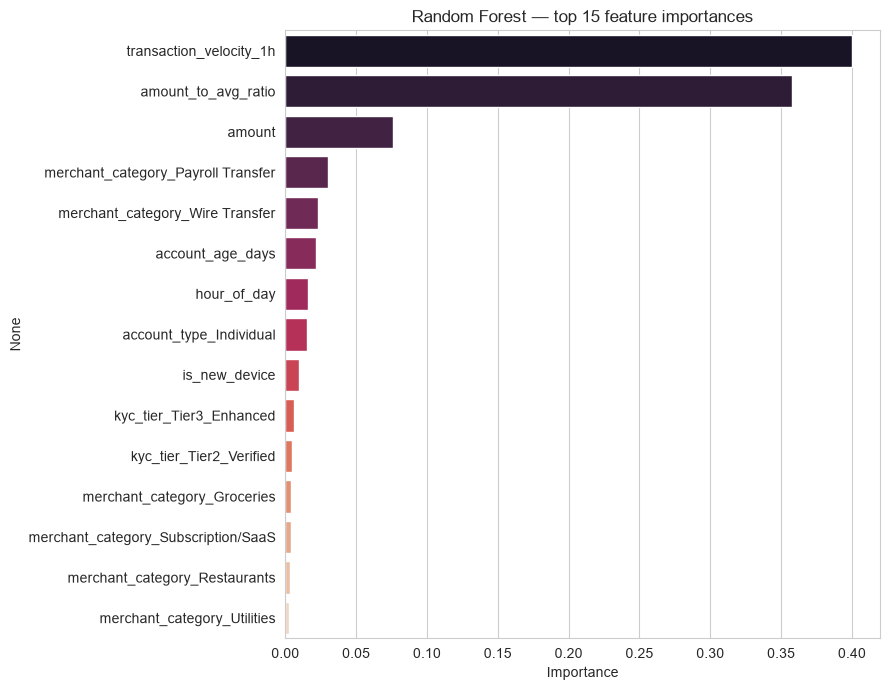

Top 10 drivers:
transaction_velocity_1h               0.3998
amount_to_avg_ratio                   0.3575
amount                                0.0758
merchant_category_Payroll Transfer    0.0302
merchant_category_Wire Transfer       0.0232
account_age_days                      0.0218
hour_of_day                           0.0158
account_type_Individual               0.0155
is_new_device                         0.0097
kyc_tier_Tier3_Enhanced               0.0059


In [37]:
importances = (pd.Series(rf.feature_importances_, index=feature_names)
               .sort_values(ascending=False))

plt.figure(figsize=(9, 7))
sns.barplot(x=importances.head(15).values, y=importances.head(15).index, palette="rocket")
plt.title("Random Forest — top 15 feature importances")
plt.xlabel("Importance"); plt.tight_layout(); plt.show()

print("Top 10 drivers:")
print(importances.head(10).round(4).to_string())

> **Insight — and this closes the loop with the EDA.** The model's top drivers are exactly the signals the
> EDA flagged: **`transaction_velocity_1h`** and **`amount_to_avg_ratio`** dominate, together accounting for
> the bulk of predictive power, followed by raw `amount` and the high-risk merchant categories (Wire/Payroll).
> This is what makes every flag **explainable**: the risk team can be shown *why* a transaction scored high
> (e.g. "5 transactions in an hour, 8× the account's normal size") rather than a black-box verdict.


---
# Conclusion & next steps

**What this prototype shows.** Replacing Finlora's fixed-threshold rules with a behaviour-aware, learned
risk score is both feasible and effective. On 126,000 transactions:

- Two validated models reach **ROC-AUC ≈ 0.93**, ranking fraud far above legitimate activity.
- Fraud is driven overwhelmingly by **behavioural, account-relative** signals — transaction velocity and
  size relative to the account's own baseline — not absolute amounts, which is precisely why static
  thresholds fail.
- Every score is **explainable** via its contributing features, and the threshold is **tunable** to the
  team's review capacity (precision reported at 70/80/90% recall).

**Model choice.** The two models are close on ROC-AUC. The **Random Forest** is the recommended primary
model for its slightly higher recall and its ability to capture non-linear interactions; the **Logistic
Regression** stays valuable as a transparent, coefficient-level baseline for governance and sanity-checking.

**Next phase (out of scope here).** Package the Random Forest behind a scoring endpoint, route scores above
the chosen threshold into a **prioritised, explainable Streamlit review queue**, log analyst outcomes to
grow a labelled dataset, and establish a periodic **retraining** cadence as fraud tactics shift.
